# 🗺️ TabPFN-3.5 Wall-to-Wall Land-Cover Prediction (Ghana)

Applies the polygon-level **TabPFN-3.5** model from `Training_TabPFN35_PolygonLevel.ipynb` to every
**Google Satellite Embedding** tile in `Images/` (64 bands, `A00`-`A63`) and produces a national 10 m
land-cover map of Ghana together with a per-pixel confidence layer and a confidence map.

## Pipeline

```
Images/*.tif ──▶ per-tile TabPFN-3.5 inference (multi-GPU workers) ──▶ mosaic
                                                                         │
                  ┌──────────────────────────────────────────────────────┴───────┐
                  ▼                                                              ▼
   class codes ─▶ 3×3 majority filter ─▶ 17-class legend       top-class probability ─▶ confidence map
                                          └▶ cartographic map
```

## Inputs

- `outputs_tabpfn35_polygon/tabpfn35_polygon_model.joblib` - the fitted `TabPFNClassifier`
  (in-context training rows = 318 polygon means).
- `outputs_tabpfn35_polygon/polygon_metrics_summary.json` - class code → class name mapping and LOO metrics.
- `outputs_tabpfn35_polygon/calibration_summary.json` - low-confidence threshold and LOO calibration.
- `Images/*.tif` - every 64-band embedding tile in this folder is classified and mosaicked.
- `new_class.xlsx` - mapping from the 23 field classes to the final 17-class legend.
- `color_code.txt` - `code R G B A name` color table of the final legend.
- `data/natural_earth_west_africa.geojson` - Natural Earth 1:10m country boundaries (public domain)
  for the cartographic map.

## How tiling works

Each tile in `Images/` is classified independently, block by block, by worker subprocesses
(`predict_tile_worker.py`, several per GPU); per-tile outputs go to a temporary folder
(`predictions_tabpfn35_polygon/temp_tiles/`). The run is **resumable**: completed tiles are skipped, and
workers write to `.partial` paths that are renamed atomically on completion, so an interrupted tile is never
mistaken for a finished one. Once every tile is done, the per-tile rasters are mosaicked, verified and
removed. Every later stage also skips work whose output already exists, so the notebook can be re-run end to
end to regenerate any product without repeating inference. `FORCE_REBUILD = True` (Section 5) recomputes
everything.

## Lossless confidence storage

The confidence mosaic stores float32 top-class probabilities with ZSTD compression and GDAL's
floating-point predictor (DEFLATE is used when the GDAL build lacks ZSTD) in 512 × 512 internal tiles. Both
are lossless: before the per-tile rasters are removed, every tile is compared bit for bit with its window in
the mosaic.

## Outputs (written to `predictions_tabpfn35_polygon/`)

| File | Contents |
|---|---|
| `predicted_classcode.tif` | Mosaic of predicted field class codes (0 = NoData). |
| `predicted_confidence.tif` | Mosaic of top-class probabilities (-1 = NoData), lossless float32. |
| `predicted_pixel_counts.csv` | Pixel counts / percentages for the 23 field classes. |
| `predicted_classcode_majority3x3.tif` | Class-code mosaic after 3×3 majority filtering. |
| `landcover_tabpfn35_final.tif` | Final 17-class land-cover map (color table embedded for GIS display). |
| `final_class_pixel_counts.csv` | Pixel counts / percentages for the final 17-class legend. |
| `final_class_land_area.csv` | Area (km²) and share of land area of each final class inside the Ghana outline (sea pixels excluded). |
| `landcover_tabpfn35_cartographic_map.png` | Cartographic land-cover map (300 dpi) with basemap, place labels, locator inset and grouped legend; also copied to `docs/`. |
| `confidence_map.png` | Top-class probability of individual 10 m pixels on a single-hue scale (no averaging). |

---

## Performance notes

Measured on NVIDIA H100 80GB GPUs (TGI RAILS cluster) with 64-band float64 3072×3072 LZW tiles on NFS; the
defaults in Section 5 follow from these measurements. End to end, classifying all 408 tiles takes about 20
hours on 4× H100.

- **Batch size.** TabPFN-3.5 saturates an H100 at roughly 25k query rows: throughput is flat from 25k to
  400k rows while peak GPU memory stays far below 80 GB. `PREDICT_BATCH_SIZE` is set to 50,000.
- **Reads are CPU-bound.** NFS delivers ~1 GB/s (a 1.3 GB tile transfers in ~1.3 s), while single-threaded
  LZW decompression of the same tile takes ~32 s. `GDAL_NUM_THREADS=2` cuts decompression ~2.2×, and each
  worker's prefetch thread overlaps the remainder with GPU inference.
- **Several workers per GPU.** A single worker leaves roughly a third of an H100 idle during TabPFN's
  CPU-side preprocessing; three concurrent workers per GPU fill those stalls (~1.5× aggregate throughput)
  within GPU memory. Each worker uses about one CPU core.
- **Mosaic memory.** `rasterio.merge` assembles each mosaic in memory: at ~72,000 × 50,000 px that is
  ~3.6 GB for the uint8 class raster and ~14.4 GB for the float32 confidence raster.

In [1]:
# ==========================================
# 1. Imports
# ==========================================
import os
import json
import time
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.windows import Window
import torch  # device detection only

import lc_eval

# The TabPFN-3.5 model is loaded only inside the per-GPU worker subprocesses
# (Section 6); this kernel orchestrates and post-processes.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Compute device available: {device}')

Compute device available: cuda


In [2]:
# ==========================================
# 2. Configure Paths
# ==========================================
MODEL_PATH = os.path.join(os.getcwd(), 'outputs_tabpfn35_polygon', 'tabpfn35_polygon_model.joblib')
METRICS_JSON_PATH = os.path.join(os.getcwd(), 'outputs_tabpfn35_polygon', 'polygon_metrics_summary.json')
CALIBRATION_JSON_PATH = os.path.join(os.getcwd(), 'outputs_tabpfn35_polygon', 'calibration_summary.json')
IMAGE_DIR = os.path.join(os.getcwd(), 'Images')
RECLASS_XLSX_PATH = os.path.join(os.getcwd(), 'new_class.xlsx')
COLOR_CODE_PATH = os.path.join(os.getcwd(), 'color_code.txt')
OUTPUT_DIR = os.path.join(os.getcwd(), 'predictions_tabpfn35_polygon')
TEMP_DIR = os.path.join(OUTPUT_DIR, 'temp_tiles')
DOCS_DIR = os.path.join(os.getcwd(), 'docs')
DOCS_MAP_PREVIEW_PATH = os.path.join(DOCS_DIR, 'landcover_tabpfn35_map_preview.png')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TEMP_DIR, exist_ok=True)
os.makedirs(DOCS_DIR, exist_ok=True)

for p in (MODEL_PATH, METRICS_JSON_PATH, CALIBRATION_JSON_PATH, IMAGE_DIR, RECLASS_XLSX_PATH, COLOR_CODE_PATH):
    assert os.path.exists(p), (
        f'Required path not found: {p}\n'
        'Run Training_TabPFN35_PolygonLevel.ipynb first to produce the TabPFN-3.5 model and its '
        'metrics, and make sure the Images/ tiles, new_class.xlsx and color_code.txt are in place '
        '(see the data link in README.md).'
    )

# Every embedding tile in IMAGE_DIR is classified and mosaicked into one raster.
image_paths = sorted(
    os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.lower().endswith('.tif')
)
assert image_paths, f'No .tif images found in: {IMAGE_DIR}'

print('Model path:      ', MODEL_PATH)
print('Metrics JSON:    ', METRICS_JSON_PATH)
print('Calibration JSON:', CALIBRATION_JSON_PATH)
print(f'Image dir:        {IMAGE_DIR}  ({len(image_paths)} tiles found)')
print('Temp dir:        ', TEMP_DIR)
print('Output dir:      ', OUTPUT_DIR)

Model path:       /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/tabpfn35_polygon_model.joblib
Metrics JSON:     /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/polygon_metrics_summary.json
Calibration JSON: /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/calibration_summary.json
Image dir:        /u/mayeh/Gh_LC/Images  (408 tiles found)
Temp dir:         /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/temp_tiles
Output dir:       /u/mayeh/Gh_LC/predictions_tabpfn35_polygon


In [3]:
# ==========================================
# 3. Class Mapping, Evaluation Summary & Calibration
# ==========================================
# The worker subprocesses each load their own copy of the model; this kernel
# reads the class list from the metrics JSON and so never allocates model
# weights on GPU 0.
with open(METRICS_JSON_PATH) as f:
    metrics = json.load(f)
code_to_name = {int(k): v for k, v in metrics['class_mapping'].items()}
classes_ = np.array(sorted(code_to_name))

print(f'Model file (loaded by the workers): {MODEL_PATH}')
print(f'Classes: {classes_.tolist()}')
print('\nClass code -> class name mapping:')
for code in sorted(code_to_name):
    print(f'  {code:2d} -> {code_to_name[code]}')

print(f'\nModel context size (independent polygons): {metrics.get("n_independent_polygons", "unknown")}')
print(f'LOO accuracy (polygon mean, polygon-held-out): {metrics.get("accuracy_polygon_mean", float("nan")):.4f}')
print(f'LOO raw-pixel accuracy (macro):                {metrics.get("raw_pixel_accuracy_macro", float("nan")):.4f}')
small_n = metrics.get('classes_with_fewer_than_10_polygons', [])
if small_n:
    print(f'[!] Classes with <10 training polygons: {[code_to_name.get(c, c) for c in small_n]}')

with open(CALIBRATION_JSON_PATH) as f:
    calibration = json.load(f)
LOW_CONFIDENCE_THRESHOLD = float(calibration['low_confidence_threshold'])
tabpfn_pixel_calibration = calibration['models']['TabPFN-3.5']['raw_pixel_polygon_weighted']
print(f'\nLow-confidence threshold: {LOW_CONFIDENCE_THRESHOLD}')
print(f'LOO held-out pixels below it were correct {tabpfn_pixel_calibration["accuracy_below"]:.1%} of the time, '
      f'at or above it {tabpfn_pixel_calibration["accuracy_at_or_above"]:.1%} (each polygon weighted equally).')

Model file (loaded by the workers): /u/mayeh/Gh_LC/outputs_tabpfn35_polygon/tabpfn35_polygon_model.joblib
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

Class code -> class name mapping:
   1 -> wetland
   2 -> mangrove20
   3 -> Woodland_Savanna
   4 -> Water
   5 -> Shrub_Crop
   6 -> Salt
   7 -> S_Flood
   8 -> Rubber
   9 -> Rice
  10 -> Palm
  11 -> P_flood
  12 -> Open_Savannah
  13 -> Open_Low_Shrubland
  14 -> Open_Forest
  15 -> Mining
  16 -> Mango
  17 -> Closed_Forest
  18 -> built-up
  19 -> Beach
  20 -> Bare_Rocks
  21 -> ANN
  22 -> cocoa
  23 -> cashew

Model context size (independent polygons): 318
LOO accuracy (polygon mean, polygon-held-out): 0.8333
LOO raw-pixel accuracy (macro):                0.8159
[!] Classes with <10 training polygons: ['Woodland_Savanna', 'Water', 'Salt', 'S_Flood', 'Rubber', 'Rice', 'P_flood', 'Open_Savannah', 'Mining', 'Closed_Forest', 'Beach', 'Bare_Rocks']

Low-confidence threshold: 0.6
LOO 

In [4]:
# ==========================================
# 4. Verify Band Layout (checked on the first tile, applied to all tiles)
# ==========================================
embedding_cols = lc_eval.EMBEDDING_COLS

def resolve_band_order(src):
    assert src.count == 64, f'Expected 64 embedding bands, found {src.count} in {src.name}'
    band_names = list(src.descriptions)
    if band_names == embedding_cols:
        return list(range(1, 65))  # rasterio band indices are 1-based
    name_to_band = {name: i + 1 for i, name in enumerate(band_names)}
    missing = [c for c in embedding_cols if c not in name_to_band]
    assert not missing, f'Image {src.name} is missing expected bands: {missing}'
    return [name_to_band[c] for c in embedding_cols]

with rasterio.open(image_paths[0]) as sample_src:
    print(f'Sample tile: {os.path.basename(image_paths[0])}')
    print(f'Image size: {sample_src.width} x {sample_src.height}  ({sample_src.width * sample_src.height:,} pixels)')
    print(f'Bands: {sample_src.count}   CRS: {sample_src.crs}')
    band_order = resolve_band_order(sample_src)
    band_names = list(sample_src.descriptions)

if band_names == embedding_cols:
    print('[✓] Band order matches the training feature order (A00..A63).')
else:
    print('[!] Band descriptions are out of order; the workers reorder them to A00..A63.')
print('All tiles in Images/ are expected to share this band layout; each worker resolves it per tile.')

Sample tile: AEF_GHANA_2025-0000000000-0000000000.tif
Image size: 3072 x 3072  (9,437,184 pixels)
Bands: 64   CRS: EPSG:4326
[✓] Band order matches the training feature order (A00..A63).
All tiles in Images/ are expected to share this band layout; each worker resolves it per tile.


In [5]:
# ==========================================
# 5. Inference Configuration
# ==========================================
# BLOCK_ROWS = 768 reads three 256-row internal GeoTIFF block rows at a time.
# Several blocks per tile let each worker's prefetch thread overlap reads with
# GPU inference.
BLOCK_ROWS = 768

# H100 throughput is flat from ~25k query rows upward with GPU memory far below
# capacity (see Performance notes).
PREDICT_BATCH_SIZE = 50_000

# Three worker processes per GPU fill the GPU while each worker runs TabPFN's
# CPU-side preprocessing; each worker uses about one CPU core, so
# N_GPU * WORKERS_PER_GPU should not exceed the core count.
WORKERS_PER_GPU = 3

# LZW decompression dominates tile reads; two GDAL threads per worker cut it ~2.2x.
GDAL_THREADS_PER_WORKER = 2

NODATA_CLASS = 0              # predicted_classcode.tif wherever any input band is NaN
NODATA_CONF = -1.0            # predicted_confidence.tif for the same pixels

# Confidence mosaic storage: float32 probabilities, lossless compression with
# the floating-point predictor, 512 x 512 internal tiles.
CONF_CODEC = lc_eval.lossless_float_codec()
CONF_STORAGE = lc_eval.lossless_float_profile(CONF_CODEC, block_size=512)

WORKER_SCRIPT = os.path.join(os.getcwd(), 'predict_tile_worker.py')
N_GPU = torch.cuda.device_count() if device == 'cuda' else 0

# ---- Stage outputs & resume behaviour --------------------------------------
# Every stage checks whether its output already exists and skips the work if
# so, which makes the notebook re-runnable top to bottom (e.g. to regenerate a
# map) without repeating the multi-hour tile inference. FORCE_REBUILD = True
# recomputes every stage.
FORCE_REBUILD = False

class_raster_path = os.path.join(OUTPUT_DIR, 'predicted_classcode.tif')
conf_raster_path = os.path.join(OUTPUT_DIR, 'predicted_confidence.tif')
majority_raster_path = os.path.join(OUTPUT_DIR, 'predicted_classcode_majority3x3.tif')
final_raster_path = os.path.join(OUTPUT_DIR, 'landcover_tabpfn35_final.tif')

mosaics_done = (
    not FORCE_REBUILD
    and os.path.exists(class_raster_path)
    and os.path.exists(conf_raster_path)
)

def tile_temp_paths(image_path):
    tile_name = os.path.splitext(os.path.basename(image_path))[0]
    return (
        os.path.join(TEMP_DIR, f'{tile_name}_classcode.tif'),
        os.path.join(TEMP_DIR, f'{tile_name}_confidence.tif'),
    )

def tile_is_done(image_path):
    class_path, conf_path = tile_temp_paths(image_path)
    return os.path.exists(class_path) and os.path.exists(conf_path)

if mosaics_done:
    remaining_tiles = []
    n_already_done = len(image_paths)
    print('[resume] Final mosaics exist; tile inference and mosaicking will be skipped.')
    print(f'  {class_raster_path}')
    print(f'  {conf_raster_path}')
    print('  (set FORCE_REBUILD = True above to redo them)')
else:
    # .partial rasters from an interrupted run are removed; those tiles are redone.
    n_partial_removed = 0
    for fname in os.listdir(TEMP_DIR):
        if fname.endswith('.partial'):
            os.remove(os.path.join(TEMP_DIR, fname))
            n_partial_removed += 1
    if n_partial_removed:
        print(f'Removed {n_partial_removed} .partial file(s) from an interrupted run.')

    remaining_tiles = [p for p in image_paths if not tile_is_done(p)]
    n_already_done = len(image_paths) - len(remaining_tiles)
    print(f'{n_already_done}/{len(image_paths)} tiles already predicted in {TEMP_DIR} and skipped.')
    print(f'{len(remaining_tiles)} tiles remaining to predict.')

n_cpus = len(os.sched_getaffinity(0))
n_workers_total = (N_GPU * WORKERS_PER_GPU) if N_GPU else 1
print(f'GPUs detected: {N_GPU if N_GPU else "0 (using CPU)"}')
print(f'CPU cores available to this job: {n_cpus}')
print(f'Worker processes: {n_workers_total}'
      + (f' ({WORKERS_PER_GPU} per GPU x {N_GPU} GPUs)' if N_GPU else ''))
if N_GPU and n_workers_total > n_cpus:
    print(f'[!] {n_workers_total} workers but only {n_cpus} core(s); each worker uses ~1 core. '
          f'Lower WORKERS_PER_GPU to {max(1, n_cpus // N_GPU)}, or request more cores.')
print(f'BLOCK_ROWS={BLOCK_ROWS}  PREDICT_BATCH_SIZE={PREDICT_BATCH_SIZE:,}  '
      f'GDAL_NUM_THREADS={GDAL_THREADS_PER_WORKER}')
print(f'Confidence mosaic storage: float32, {CONF_CODEC.upper()} + floating-point predictor (lossless)')

[resume] Final mosaics exist; tile inference and mosaicking will be skipped.
  /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/predicted_classcode.tif
  /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/predicted_confidence.tif
  (set FORCE_REBUILD = True above to redo them)
GPUs detected: 4
CPU cores available to this job: 16
Worker processes: 12 (3 per GPU x 4 GPUs)
BLOCK_ROWS=768  PREDICT_BATCH_SIZE=50,000  GDAL_NUM_THREADS=2
Confidence mosaic storage: float32, ZSTD + floating-point predictor (lossless)


In [6]:
# ==========================================
# 6. Multi-GPU Block-wise Inference (parallel subprocess workers, resumable)
# ==========================================
# WORKERS_PER_GPU worker processes run per GPU, each pinned to its GPU through
# CUDA_VISIBLE_DEVICES. Tiles are dealt round-robin across all workers so each
# receives a similar mix of dense and mostly-NoData tiles; a worker also skips
# any tile that is already complete.
#
# A kernel interrupt raises KeyboardInterrupt in this process only; the handler
# below terminates the worker subprocesses so none keep running in the
# background, and the next run resumes from the completed tiles.

worker_list_dir = os.path.join(OUTPUT_DIR, 'worker_tile_lists')
worker_log_dir = os.path.join(OUTPUT_DIR, 'worker_logs')
os.makedirs(worker_list_dir, exist_ok=True)
os.makedirs(worker_log_dir, exist_ok=True)

if remaining_tiles:
    # One entry per worker process: (gpu_id, tag), e.g. gpu0_w0, gpu0_w1, gpu0_w2, gpu1_w0, ...
    if N_GPU:
        worker_specs = [
            (gpu_id, f'gpu{gpu_id}_w{w}')
            for gpu_id in range(N_GPU)
            for w in range(WORKERS_PER_GPU)
        ]
    else:
        worker_specs = [(None, 'cpu')]

    tile_splits = [remaining_tiles[i::len(worker_specs)] for i in range(len(worker_specs))]

    procs = []
    log_handles = []
    log_paths = {}

    for (gpu_id, tag), tiles in zip(worker_specs, tile_splits):
        if not tiles:
            continue

        tiles_file = os.path.join(worker_list_dir, f'{tag}_tiles.json')
        with open(tiles_file, 'w') as f:
            json.dump(tiles, f)

        log_path = os.path.join(worker_log_dir, f'{tag}.log')
        log_paths[tag] = log_path
        log_f = open(log_path, 'w')
        log_handles.append(log_f)

        env = os.environ.copy()
        if gpu_id is not None:
            env['CUDA_VISIBLE_DEVICES'] = str(gpu_id)
        # Decompression threads for this worker's prefetch reads.
        env['GDAL_NUM_THREADS'] = str(GDAL_THREADS_PER_WORKER)
        # One BLAS/OMP thread per worker keeps concurrent workers from contending for cores.
        env['OMP_NUM_THREADS'] = '1'
        env['MKL_NUM_THREADS'] = '1'

        cmd = [
            sys.executable, WORKER_SCRIPT,
            '--gpu-tag', tag,
            '--model-path', MODEL_PATH,
            '--tiles-file', tiles_file,
            '--temp-dir', TEMP_DIR,
            '--block-rows', str(BLOCK_ROWS),
            '--batch-size', str(PREDICT_BATCH_SIZE),
            '--nodata-class', str(NODATA_CLASS),
            '--nodata-conf', str(NODATA_CONF),
        ]
        print(f'Launching worker [{tag}]: {len(tiles)} tiles -> log: {log_path}')
        procs.append(subprocess.Popen(cmd, stdout=log_f, stderr=subprocess.STDOUT, env=env))

    print(f'\n{len(procs)} worker process(es) running across {N_GPU or 0} GPU(s).')

    start_time = time.time()
    try:
        while any(p.poll() is None for p in procs):
            time.sleep(15)
            n_done_now = sum(1 for p in image_paths if tile_is_done(p))
            elapsed = time.time() - start_time
            n_this_run = n_done_now - n_already_done
            rate = f', {n_this_run / (elapsed / 60):.2f} tiles/min' if n_this_run else ''
            eta = ''
            if n_this_run:
                remaining = len(image_paths) - n_done_now
                eta = f', ETA {remaining / (n_this_run / elapsed) / 3600:.1f} h'
            print(f'  [{elapsed / 60:.1f} min] {n_done_now}/{len(image_paths)} tiles complete{rate}{eta}')
    except KeyboardInterrupt:
        print('\nInterrupted: stopping GPU worker processes...')
        for p in procs:
            if p.poll() is None:
                p.terminate()
        for p in procs:
            try:
                p.wait(timeout=30)
            except subprocess.TimeoutExpired:
                p.kill()
        print('Workers stopped. Re-run this cell (or restart from Section 5) to resume; '
              'completed tiles are skipped automatically.')
        raise
    finally:
        for log_f in log_handles:
            log_f.close()

    failed = [(tag, p.returncode) for tag, p in zip(log_paths, procs) if p.returncode != 0]
    if failed:
        for tag, _ in failed:
            print(f'--- tail of {log_paths[tag]} ---')
            with open(log_paths[tag]) as f:
                print(''.join(f.readlines()[-20:]))
        raise RuntimeError(f'Worker process(es) failed: {failed}; see the log tails above.')

    total_elapsed = time.time() - start_time
    print(f'\n[✓] All GPU workers finished in {total_elapsed / 60:.1f} minutes.')
else:
    print('No tiles left to predict; inference skipped.')

if mosaics_done:
    print('[resume] Final mosaics exist; per-tile outputs are not needed.')
else:
    missing = [p for p in image_paths if not tile_is_done(p)]
    assert not missing, f'{len(missing)} tiles still missing predictions after workers finished: {missing[:5]}'

    temp_class_paths = [tile_temp_paths(p)[0] for p in image_paths]
    temp_conf_paths = [tile_temp_paths(p)[1] for p in image_paths]
    print(f'Per-tile temp rasters ready in: {TEMP_DIR}')

No tiles left to predict; inference skipped.
[resume] Final mosaics exist; per-tile outputs are not needed.


In [7]:
# ==========================================
# 6b. Mosaic Per-Tile Outputs, Verify, Remove Temp Folder
# ==========================================
# BIGTIFF='YES' is set explicitly: the confidence mosaic exceeds the 4 GiB limit
# of classic TIFF, and GDAL's size heuristic for compressed output can
# otherwise select classic TIFF.
BIGTIFF_OPTION = 'YES'

if mosaics_done:
    print('[resume] Mosaics exist; mosaicking skipped.')
else:
    print(f'Mosaicking {len(temp_class_paths)} class-code tiles...')
    class_srcs = [rasterio.open(p) for p in temp_class_paths]
    mosaic_class, mosaic_transform = merge(class_srcs, nodata=NODATA_CLASS)
    class_out_profile = class_srcs[0].profile.copy()
    class_out_profile.update(
        height=mosaic_class.shape[1], width=mosaic_class.shape[2], transform=mosaic_transform,
        BIGTIFF=BIGTIFF_OPTION,
    )
    with rasterio.open(class_raster_path, 'w', **class_out_profile) as dst:
        dst.write(mosaic_class)
    for s in class_srcs:
        s.close()
    del mosaic_class
    print(f'Saved mosaicked classified raster: {class_raster_path}')

    print(f'Mosaicking {len(temp_conf_paths)} confidence tiles...')
    conf_srcs = [rasterio.open(p) for p in temp_conf_paths]
    mosaic_conf, conf_transform = merge(conf_srcs, nodata=NODATA_CONF)
    conf_out_profile = conf_srcs[0].profile.copy()
    conf_out_profile.update(
        height=mosaic_conf.shape[1], width=mosaic_conf.shape[2], transform=conf_transform,
        **CONF_STORAGE,
    )
    t0 = time.time()
    with rasterio.open(conf_raster_path, 'w', **conf_out_profile) as dst:
        dst.write(mosaic_conf)
    for s in conf_srcs:
        s.close()
    raw_gb = mosaic_conf.nbytes / 1e9
    del mosaic_conf
    print(f'Saved mosaicked confidence raster: {conf_raster_path} '
          f'({os.path.getsize(conf_raster_path) / 1e9:.2f} GB on disk, {raw_gb:.2f} GB uncompressed, '
          f'{CONF_CODEC.upper()} + floating-point predictor, {(time.time() - t0) / 60:.1f} min)')

    # Bit-exact comparison of every per-tile raster with its window in the
    # mosaics; the temp folder is removed only if all tiles match.
    print('\nVerifying mosaics against the per-tile rasters...')
    lc_eval.verify_mosaic_against_tiles(class_raster_path, temp_class_paths)
    lc_eval.verify_mosaic_against_tiles(conf_raster_path, temp_conf_paths)
    print(f'[✓] All {len(image_paths)} tiles are bit-identical to their windows in both mosaics.')

    shutil.rmtree(TEMP_DIR)
    print(f'Deleted temp folder: {TEMP_DIR}')

[resume] Mosaics exist; mosaicking skipped.


In [8]:
# ==========================================
# 7. Per-Class Pixel Count Summary (23 field classes)
# ==========================================
summary_csv_path = os.path.join(OUTPUT_DIR, 'predicted_pixel_counts.csv')

if (not FORCE_REBUILD) and os.path.exists(summary_csv_path):
    summary_df = pd.read_csv(summary_csv_path)
    print(f'[resume] Loaded existing class pixel-count summary: {summary_csv_path}')
else:
    # The class mosaic is streamed from disk in row blocks.
    COUNT_BLOCK_ROWS = 4096
    counts256 = np.zeros(256, dtype=np.int64)
    with rasterio.open(class_raster_path) as src:
        for row0 in range(0, src.height, COUNT_BLOCK_ROWS):
            row1 = min(row0 + COUNT_BLOCK_ROWS, src.height)
            block = src.read(1, window=Window(0, row0, src.width, row1 - row0))
            counts256 += np.bincount(block.ravel(), minlength=256)

    pixel_counts = {int(c): int(counts256[int(c)]) for c in classes_}
    pixel_counts[NODATA_CLASS] = int(counts256[NODATA_CLASS])
    total_valid = sum(v for k, v in pixel_counts.items() if k != NODATA_CLASS)

    summary_rows = []
    for code in sorted(pixel_counts):
        name = 'NoData' if code == NODATA_CLASS else code_to_name.get(code, f'Class_{code}')
        count = pixel_counts[code]
        pct = (count / total_valid * 100) if (code != NODATA_CLASS and total_valid > 0) else np.nan
        summary_rows.append({'code': code, 'name': name, 'pixel_count': count, 'pct_of_classified_area': pct})

    summary_df = pd.DataFrame(summary_rows).sort_values('code').reset_index(drop=True)
    summary_df.to_csv(summary_csv_path, index=False)
    print(f'Saved class pixel-count summary: {summary_csv_path}')

display(summary_df)

[resume] Loaded existing class pixel-count summary: /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/predicted_pixel_counts.csv


,code,name,pixel_count,pct_of_classified_area
0,0,NoData,1131739726,NaN
1,1,wetland,41415116,1.682485
2,2,mangrove20,5212718,0.211766
3,3,Woodland_Savanna,168033847,6.826358
4,4,Water,116449841,4.730763
5,5,Shrub_Crop,223747510,9.089720
6,6,Salt,2076874,0.084373
7,7,S_Flood,36096137,1.466402
8,8,Rubber,29117081,1.182878
9,9,Rice,105714008,4.294621


In [9]:
# ==========================================
# 8. Post-Classification Smoothing: 3x3 Majority Filter
# ==========================================
# Each pixel takes the most common class in its 3x3 neighbourhood, removing
# isolated single-pixel noise from per-pixel classification. Rules:
#   - NoData (0) pixels stay NoData and never vote.
#   - Ties keep the center pixel's class.
# The mosaic is processed in row blocks read with a 1-pixel halo (boundless
# reads fill the halo with NoData at the raster edges).
FILTER_BLOCK_ROWS = 1024

if (not FORCE_REBUILD) and os.path.exists(majority_raster_path):
    print(f'[resume] Majority-filtered raster exists; skipped: {majority_raster_path}')
else:
    t0 = time.time()
    with rasterio.open(class_raster_path) as src:
        height, width = src.height, src.width
        filter_profile = src.profile.copy()
        filter_profile.update(BIGTIFF=BIGTIFF_OPTION)

        with rasterio.open(majority_raster_path, 'w', **filter_profile) as dst:
            n_blocks = int(np.ceil(height / FILTER_BLOCK_ROWS))
            for bi, row0 in enumerate(range(0, height, FILTER_BLOCK_ROWS)):
                row1 = min(row0 + FILTER_BLOCK_ROWS, height)

                # Block plus a 1-pixel halo on every side; outside the raster the
                # halo is NoData, which never votes.
                padded = src.read(
                    1,
                    window=Window(-1, row0 - 1, width + 2, (row1 - row0) + 2),
                    boundless=True,
                    fill_value=NODATA_CLASS,
                )
                center = padded[1:-1, 1:-1]

                # Vote counting: for each class present in the padded block, sum its
                # nine 3x3-shifted occurrence masks (counts fit in uint8: max 9),
                # tracking the winning class, its count, and each center pixel's own
                # class count for the keep-center-on-tie rule.
                best_count = np.zeros(center.shape, dtype=np.uint8)
                best_class = center.copy()
                center_count = np.zeros(center.shape, dtype=np.uint8)

                for c in np.unique(padded):
                    if c == NODATA_CLASS:
                        continue
                    mask = (padded == c).astype(np.uint8)
                    votes = (
                        mask[:-2, :-2] + mask[:-2, 1:-1] + mask[:-2, 2:]
                        + mask[1:-1, :-2] + mask[1:-1, 1:-1] + mask[1:-1, 2:]
                        + mask[2:, :-2] + mask[2:, 1:-1] + mask[2:, 2:]
                    )
                    improved = votes > best_count
                    best_count[improved] = votes[improved]
                    best_class[improved] = c
                    is_c = center == c
                    center_count[is_c] = votes[is_c]

                filtered = np.where(center_count >= best_count, center, best_class)
                filtered[center == NODATA_CLASS] = NODATA_CLASS

                dst.write(filtered.astype(np.uint8), 1, window=Window(0, row0, width, row1 - row0))

                if (bi + 1) % 10 == 0 or (bi + 1) == n_blocks:
                    print(f'  Majority filter: block {bi + 1}/{n_blocks} '
                          f'({(time.time() - t0) / 60:.1f} min elapsed)')

    print(f'\n[✓] 3x3 majority filter complete in {(time.time() - t0) / 60:.1f} minutes.')
    print(f'Saved majority-filtered raster: {majority_raster_path}')

[resume] Majority-filtered raster exists; skipped: /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/predicted_classcode_majority3x3.tif


In [10]:
# ==========================================
# 9. Reclassification: 23 Field Classes -> Final 17-Class Legend
# ==========================================
# new_class.xlsx maps every field class (1-23) to the final land-cover legend,
# merging thematically equivalent classes (e.g. cocoa, cashew, rubber, palm and
# mango become Tree Crop Plantation). color_code.txt defines the final legend's
# codes, names and RGBA display colors. The legend and mapping are always loaded
# (later sections use them); the raster rewrite is skipped when its output exists.
new_code_to_name, new_code_to_rgba = lc_eval.load_color_table(COLOR_CODE_PATH)

print('Final legend (color_code.txt):')
for c in sorted(new_code_to_name):
    print(f'  {c:2d} -> {new_code_to_name[c]}  RGBA{new_code_to_rgba[c]}')

reclass_lut, reclass_df = lc_eval.load_reclass_lut(RECLASS_XLSX_PATH)
print('\nOld -> new class mapping:')
print(reclass_df.to_string(index=False))

# Every field class is mapped, and every new code exists in the legend.
unmapped_old = sorted(int(c) for c in classes_ if reclass_lut[int(c)] == 0)
assert not unmapped_old, f'Old class codes missing from new_class.xlsx: {unmapped_old}'
unknown_new = sorted(set(int(c) for c in reclass_df['New Class Code']) - set(new_code_to_name))
assert not unknown_new, f'New class codes absent from color_code.txt: {unknown_new}'
print('\n[✓] Reclassification table validated against the color legend.')

final_counts_csv_path = os.path.join(OUTPUT_DIR, 'final_class_pixel_counts.csv')
final_counts = None

if (not FORCE_REBUILD) and os.path.exists(final_raster_path):
    print(f'\n[resume] Final land-cover raster exists; reclassification skipped: {final_raster_path}')
else:
    t0 = time.time()
    with rasterio.open(majority_raster_path) as src:
        final_profile = src.profile.copy()
        final_profile.update(nodata=NODATA_CLASS, BIGTIFF=BIGTIFF_OPTION)

        with rasterio.open(final_raster_path, 'w', **final_profile) as dst:
            for row0 in range(0, src.height, FILTER_BLOCK_ROWS):
                row1 = min(row0 + FILTER_BLOCK_ROWS, src.height)
                window = Window(0, row0, src.width, row1 - row0)
                block = reclass_lut[src.read(1, window=window)]
                if final_counts is None:
                    final_counts = np.zeros(256, dtype=np.int64)
                final_counts += np.bincount(block.ravel(), minlength=256)
                dst.write(block, 1, window=window)

            # Embedded color table: QGIS/ArcGIS render the legend colors directly.
            dst.write_colormap(1, new_code_to_rgba)

    print(f'[✓] Reclassification complete in {(time.time() - t0) / 60:.1f} minutes.')
    print(f'Saved final land-cover map: {final_raster_path}')

if final_counts is None and (not FORCE_REBUILD) and os.path.exists(final_counts_csv_path):
    final_summary_df = pd.read_csv(final_counts_csv_path)
    print(f'[resume] Loaded existing final class pixel-count summary: {final_counts_csv_path}')
else:
    if final_counts is None:
        final_counts = np.zeros(256, dtype=np.int64)
        with rasterio.open(final_raster_path) as src:
            for row0 in range(0, src.height, FILTER_BLOCK_ROWS):
                row1 = min(row0 + FILTER_BLOCK_ROWS, src.height)
                block = src.read(1, window=Window(0, row0, src.width, row1 - row0))
                final_counts += np.bincount(block.ravel(), minlength=256)

    total_valid_final = int(final_counts[1:].sum())
    final_summary_df = pd.DataFrame([
        {
            'code': c,
            'name': 'NoData' if c == NODATA_CLASS else new_code_to_name[c],
            'pixel_count': int(final_counts[c]),
            'pct_of_classified_area': (final_counts[c] / total_valid_final * 100)
            if (c != NODATA_CLASS and total_valid_final > 0) else np.nan,
        }
        for c in sorted(new_code_to_name)
    ])
    final_summary_df.to_csv(final_counts_csv_path, index=False)
    print(f'Saved final class pixel-count summary: {final_counts_csv_path}')

display(final_summary_df)

Final legend (color_code.txt):
   0 -> NoData / Unclassified  RGBA(0, 0, 0, 0)
   1 -> Swamp  RGBA(65, 182, 196, 255)
   2 -> Mangrove  RGBA(0, 90, 50, 255)
   3 -> Closed Savannah  RGBA(161, 217, 155, 255)
   4 -> Water  RGBA(8, 81, 156, 255)
   5 -> Shrub Crop  RGBA(223, 194, 125, 255)
   6 -> Mining  RGBA(140, 81, 10, 255)
   7 -> Seasonally Flooded Woody  RGBA(107, 174, 214, 255)
   8 -> Tree Crop Plantation  RGBA(255, 72, 190, 255)
   9 -> Annual Herbaceous Cultivation  RGBA(255, 237, 111, 255)
  10 -> Permanently Flooded Woody  RGBA(49, 130, 189, 255)
  11 -> Open Savannah  RGBA(254, 204, 92, 255)
  12 -> Open Low Shrubland  RGBA(253, 141, 60, 255)
  13 -> Open Forest  RGBA(65, 171, 93, 255)
  14 -> Closed Forest  RGBA(0, 68, 27, 255)
  15 -> Built up  RGBA(227, 26, 28, 255)
  16 -> Beaches  RGBA(255, 255, 178, 255)
  17 -> Bare Rocks  RGBA(115, 115, 115, 255)

Old -> new class mapping:
 Old Class Code          Old Class                     New Class  New Class Code
             

,code,name,pixel_count,pct_of_classified_area
0,0,NoData,1131739726,NaN
1,1,Swamp,41366779,1.680521
2,2,Mangrove,5180906,0.210474
3,3,Closed Savannah,168242491,6.834834
4,4,Water,116512113,4.733293
5,5,Shrub Crop,225584969,9.164366
6,6,Mining,21571773,0.876351
7,7,Seasonally Flooded Woody,35460506,1.440579
8,8,Tree Crop Plantation,301224226,12.237203
9,9,Annual Herbaceous Cultivation,611324218,24.834984


[resume] Loaded land area by class: /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/final_class_land_area.csv
Mapped land area inside the Ghana outline: 238,836 km²


,code,name,pixel_count,area_km2,pct_of_land_area
0,1,Swamp,41239768,4085.74,1.71
1,2,Mangrove,5072913,503.96,0.21
2,3,Closed Savannah,168057654,16577.62,6.94
3,4,Water,87987804,8706.21,3.65
4,5,Shrub Crop,224643562,22263.10,9.32
5,6,Mining,21441921,2127.58,0.89
6,7,Seasonally Flooded Woody,34805228,3431.14,1.44
7,8,Tree Crop Plantation,300600465,29797.65,12.48
8,9,Annual Herbaceous Cultivation,605099197,59590.63,24.95
9,10,Permanently Flooded Woody,1563796,155.43,0.07


Preview array: (4233, 2937) (mode of each 17 x 17 px block)


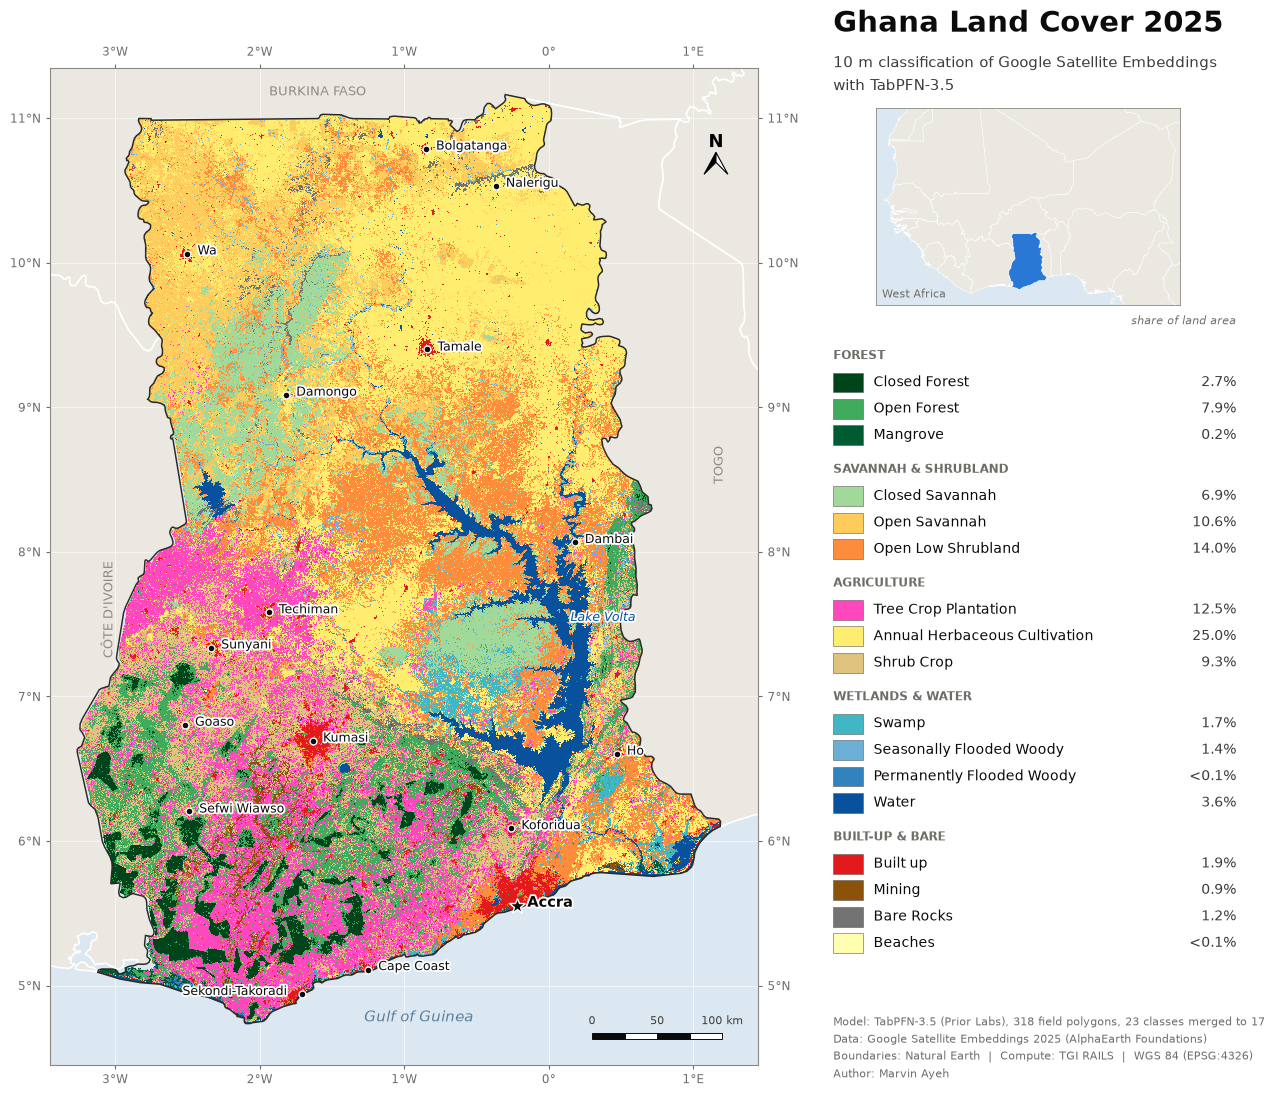

Saved cartographic map: /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/landcover_tabpfn35_cartographic_map.png
README preview updated: /u/mayeh/Gh_LC/docs/landcover_tabpfn35_map_preview.png


In [11]:
# ==========================================
# 10. Cartographic Land-Cover Map
# ==========================================
# National map of the final 17-class legend (drawing code: lc_maps.py).
#   - Classes are read at map resolution with mode resampling: each map pixel
#     shows the most common class of the 10 m pixels it covers.
#   - Basemap: Natural Earth 1:10m country boundaries
#     (data/natural_earth_west_africa.geojson) - Ghana outline, neighbouring
#     countries and sea. Class pixels outside the Ghana outline are not drawn.
#   - Legend: classes grouped by theme, each with its share of the land area,
#     measured on the full-resolution map inside the Ghana outline
#     (final_class_land_area.csv).
import matplotlib.pyplot as plt

import lc_maps

BASEMAP_PATH = os.path.join(os.getcwd(), 'data', 'natural_earth_west_africa.geojson')
TARGET_PREVIEW_WIDTH = 3000
MAP_EXTENT = (-3.45, 1.45, 4.45, 11.35)   # lon0, lon1, lat0, lat1

LEGEND_GROUPS = [
    ('Forest', [14, 13, 2]),
    ('Savannah & shrubland', [3, 11, 12]),
    ('Agriculture', [8, 9, 5]),
    ('Wetlands & water', [1, 7, 10, 4]),
    ('Built-up & bare', [15, 6, 17, 16]),
]
# The capitals of Ghana's 16 regions; Accra is also the national capital. Coordinates:
# Natural Earth populated places; Techiman, Goaso, Dambai, Damongo and Nalerigu from
# Wikipedia; Sefwi Wiawso from OpenStreetMap.
PLACES = [
    ('Accra', -0.219, 5.552, 'capital', 'right'),
    ('Kumasi', -1.632, 6.692, 'city', 'right'),
    ('Tamale', -0.840, 9.400, 'city', 'right'),
    ('Sekondi-Takoradi', -1.704, 4.943, 'city', 'left'),
    ('Cape Coast', -1.250, 5.110, 'city', 'right'),
    ('Koforidua', -0.260, 6.090, 'city', 'right'),
    ('Ho', 0.470, 6.600, 'city', 'right'),
    ('Sunyani', -2.336, 7.336, 'city', 'right'),
    ('Bolgatanga', -0.850, 10.790, 'city', 'right'),
    ('Wa', -2.500, 10.060, 'city', 'right'),
    ('Techiman', -1.936, 7.583, 'city', 'right'),
    ('Goaso', -2.517, 6.800, 'city', 'right'),
    ('Sefwi Wiawso', -2.488, 6.205, 'city', 'right'),
    ('Dambai', 0.179, 8.069, 'city', 'right'),
    ('Damongo', -1.817, 9.083, 'city', 'right'),
    ('Nalerigu', -0.367, 10.533, 'city', 'right'),
]
MAP_LABELS = [
    ("CÔTE D'IVOIRE", -3.05, 7.60, 'neighbour_vertical'),
    ('BURKINA FASO', -1.60, 11.18, 'neighbour'),
    ('TOGO', 1.18, 8.60, 'neighbour_vertical'),
    ('Gulf of Guinea', -0.90, 4.78, 'sea'),
    ('Lake Volta', 0.15, 7.55, 'lake'),
]
legend_codes = sorted(c for _, codes in LEGEND_GROUPS for c in codes)
assert legend_codes == sorted(c for c in new_code_to_name if c != NODATA_CLASS), \
    'LEGEND_GROUPS must list every class of color_code.txt exactly once.'

basemap = lc_maps.load_basemap(BASEMAP_PATH)
ghana = lc_maps.country_feature(basemap, 'GHA')

# Land area of every final class inside the Ghana outline (full resolution).
land_area_csv_path = os.path.join(OUTPUT_DIR, 'final_class_land_area.csv')
if (not FORCE_REBUILD) and os.path.exists(land_area_csv_path):
    land_area_df = pd.read_csv(land_area_csv_path)
    print(f'[resume] Loaded land area by class: {land_area_csv_path}')
else:
    t0 = time.time()
    area = lc_maps.land_area_by_class(final_raster_path, ghana['geometry'], nodata=NODATA_CLASS)
    land_area_df = pd.DataFrame({
        'code': area.index.astype(int),
        'name': [new_code_to_name[int(c)] for c in area.index],
        'pixel_count': area['pixel_count'].to_numpy(),
        'area_km2': area['area_km2'].to_numpy(),
    })
    land_area_df['pct_of_land_area'] = land_area_df['area_km2'] / land_area_df['area_km2'].sum() * 100
    land_area_df.to_csv(land_area_csv_path, index=False)
    print(f'Land area by class computed in {(time.time() - t0) / 60:.1f} min: {land_area_csv_path}')
print(f'Mapped land area inside the Ghana outline: {land_area_df["area_km2"].sum():,.0f} km²')
display(land_area_df.round(2))
area_share = dict(zip(land_area_df['code'].astype(int), land_area_df['pct_of_land_area'] / 100))

preview, bounds, downsample = lc_maps.read_class_preview(final_raster_path, TARGET_PREVIEW_WIDTH, 'mode')
print(f'Preview array: {preview.shape} (mode of each {downsample} x {downsample} px block)')

credits = (
    f'Model: TabPFN-3.5 (Prior Labs), {metrics["n_independent_polygons"]} field polygons, '
    f'{metrics["n_classes"]} classes merged to {len(legend_codes)}\n'
    'Data: Google Satellite Embeddings 2025 (AlphaEarth Foundations)\n'
    'Boundaries: Natural Earth  |  Compute: TGI RAILS  |  WGS 84 (EPSG:4326)\n'
    'Author: Marvin Ayeh'
)
fig = lc_maps.cartographic_landcover_map(
    preview, bounds, basemap, ghana, LEGEND_GROUPS, new_code_to_name, new_code_to_rgba, area_share,
    title='Ghana Land Cover 2025',
    subtitle='10 m classification of Google Satellite Embeddings\nwith TabPFN-3.5',
    credits=credits, places=PLACES, labels=MAP_LABELS, extent=MAP_EXTENT,
)

carto_map_path = os.path.join(OUTPUT_DIR, 'landcover_tabpfn35_cartographic_map.png')
fig.savefig(carto_map_path, dpi=300, facecolor='white')
plt.show()
plt.close(fig)
shutil.copyfile(carto_map_path, DOCS_MAP_PREVIEW_PATH)
print(f'Saved cartographic map: {carto_map_path}')
print(f'README preview updated: {DOCS_MAP_PREVIEW_PATH}')

Preview array: (4233, 2937) (every 17th pixel in each direction)
Displayed pixels: 8,516,577 | mean top-class probability 0.583 | 56.2% below 0.6


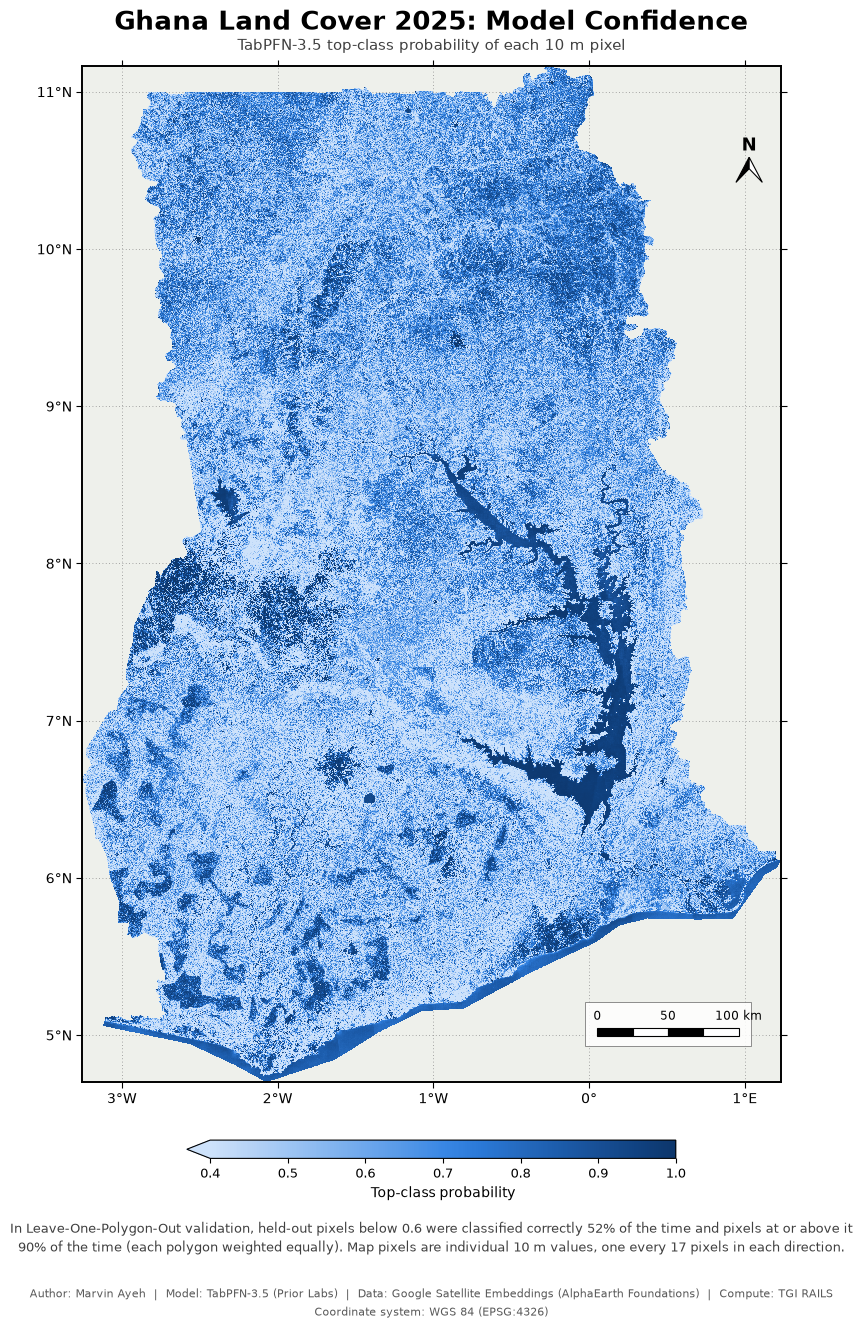

Saved confidence map: /u/mayeh/Gh_LC/predictions_tabpfn35_polygon/confidence_map.png


In [12]:
# ==========================================
# 11. Confidence Map
# ==========================================
# Raw per-pixel confidence (TabPFN-3.5 top-class probability), read at map
# resolution by nearest-neighbour sampling, so every map pixel shows the value
# of one 10 m pixel, without averaging.
# Single-hue scale from light (low confidence) to dark (high confidence),
# spanning CONF_MAP_VMIN to 1.0; values below CONF_MAP_VMIN take the lightest shade.
from matplotlib.colors import LinearSegmentedColormap

CONF_MAP_VMIN = 0.4
MAP_FIGSIZE = (9.5, 13.2)
ATTRIBUTION = ('Author: Marvin Ayeh  |  Model: TabPFN-3.5 (Prior Labs)  |  '
               'Data: Google Satellite Embeddings (AlphaEarth Foundations)  |  Compute: TGI RAILS\n'
               'Coordinate system: WGS 84 (EPSG:4326)')

with rasterio.Env(GDAL_NUM_THREADS='ALL_CPUS'):
    with rasterio.open(conf_raster_path) as src:
        conf_downsample = max(1, int(np.ceil(src.width / TARGET_PREVIEW_WIDTH)))
        conf_preview = src.read(
            1,
            out_shape=(max(1, src.height // conf_downsample), max(1, src.width // conf_downsample)),
            resampling=Resampling.nearest,
        )
        conf_bounds = src.bounds

displayed = conf_preview[conf_preview >= 0]
print(f'Preview array: {conf_preview.shape} (every {conf_downsample}th pixel in each direction)')
print(f'Displayed pixels: {displayed.size:,} | mean top-class probability {displayed.mean():.3f} | '
      f'{np.mean(displayed < LOW_CONFIDENCE_THRESHOLD):.1%} below {LOW_CONFIDENCE_THRESHOLD}')

conf_cmap = LinearSegmentedColormap.from_list('confidence', lc_eval.BLUE_RAMP)
conf_cmap.set_bad((0, 0, 0, 0))

fig, ax = plt.subplots(figsize=MAP_FIGSIZE)
im = ax.imshow(np.ma.masked_less(conf_preview, 0), cmap=conf_cmap, vmin=CONF_MAP_VMIN, vmax=1.0,
               extent=[conf_bounds.left, conf_bounds.right, conf_bounds.bottom, conf_bounds.top],
               interpolation='nearest', zorder=2)
center_lat = lc_maps.style_map_axes(ax, conf_bounds)
lc_maps.add_map_titles(ax, 'Ghana Land Cover 2025: Model Confidence',
                       'TabPFN-3.5 top-class probability of each 10 m pixel')
lc_maps.add_north_arrow(ax)
lc_maps.add_scale_bar(ax, conf_bounds, center_lat)

cax = ax.inset_axes([0.15, -0.075, 0.70, 0.018])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='min')
cbar.set_label('Top-class probability', fontsize=10)
cbar.ax.tick_params(labelsize=9)
ax.text(0.5, -0.135,
        f'In Leave-One-Polygon-Out validation, held-out pixels below {LOW_CONFIDENCE_THRESHOLD:.1f} were classified '
        f'correctly {tabpfn_pixel_calibration["accuracy_below"]:.0%} of the time and pixels at or above it\n'
        f'{tabpfn_pixel_calibration["accuracy_at_or_above"]:.0%} of the time (each polygon weighted equally). '
        f'Map pixels are individual 10 m values, one every {conf_downsample} pixels in each direction.',
        transform=ax.transAxes, ha='center', va='top', fontsize=9, color='0.25', linespacing=1.5)
lc_maps.add_attribution(ax, ATTRIBUTION, y=-0.20)

confidence_map_path = os.path.join(OUTPUT_DIR, 'confidence_map.png')
plt.savefig(confidence_map_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print(f'Saved confidence map: {confidence_map_path}')

In [13]:
# ==========================================
# 12. Done
# ==========================================
print('Outputs saved to:', OUTPUT_DIR)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    print(' -', fname)

Outputs saved to: /u/mayeh/Gh_LC/predictions_tabpfn35_polygon
 - confidence_map.png
 - final_class_land_area.csv
 - final_class_pixel_counts.csv
 - landcover_tabpfn35_cartographic_map.png
 - landcover_tabpfn35_final.tif
 - predicted_classcode.tif
 - predicted_classcode_majority3x3.tif
 - predicted_confidence.tif
 - predicted_pixel_counts.csv
 - temp_tiles
 - worker_logs
 - worker_tile_lists
